# Diffusion Map on XY configurations

This notebook loads XY-model configurations saved via `build_xy_dataset` in `xy_sim.py`, builds a feature matrix, and runs a diffusion map embedding to visualize the temperature manifold.

In [12]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Path to the compressed dataset produced by build_xy_dataset
DATA_PATH = Path('xy_dataset_wolff.npz')
METADATA_PATH = Path('xy_dataset_wolff.metadata.json')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset {DATA_PATH} not found. Update DATA_PATH to point to your file.")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file {METADATA_PATH} not found.")

with np.load(DATA_PATH) as npz:
    configurations = npz['configurations']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

num_samples, num_sites = configurations.shape
print(f"Loaded {num_samples} samples with {num_sites} lattice sites each.")


Loaded 2990 samples with 1024 lattice sites each.


In [13]:
# Convert flattened angles (radians) into (cos, sin) features per site
angles = configurations.astype(np.float64)
features = np.stack([np.cos(angles), np.sin(angles)], axis=-1)
features = features.reshape(num_samples, -1)
print(f"Feature matrix shape: {features.shape}")

# Extract temperatures for coloring
temperatures = np.array([entry['temperature'] for entry in metadata], dtype=np.float64)
assert temperatures.shape[0] == num_samples


Feature matrix shape: (2990, 2048)


In [14]:
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import normalize

# Diffusion map helper

def diffusion_map(data, epsilon=None, n_components=5):
    # Pairwise Euclidean distances
    dists = pairwise_distances(data, metric='euclidean')
    if epsilon is None:
        # median of squared distances as heuristic bandwidth
        eps = np.median(dists ** 2)
        epsilon = max(eps, 1e-12)
    kernel = np.exp(-(dists ** 2) / epsilon)
    # Normalize to Markov matrix
    row_sums = kernel.sum(axis=1, keepdims=True)
    P = kernel / row_sums
    # Symmetrize for stable eigendecomposition
    D_half = np.sqrt(row_sums)
    A = kernel / (D_half @ D_half.T)
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(A)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # Skip the first eigenvector (constant mode)
    diffusion_coords = eigvecs[:, 1:n_components+1]
    diffusion_vals = eigvals[1:n_components+1]
    # Normalize coordinates by eigenvalues (diffusion map convention)
    diffusion_coords = diffusion_coords * diffusion_vals
    return diffusion_coords, diffusion_vals, epsilon

embeddings, lambdas, eps = diffusion_map(features, n_components=5)
print("Eigenvalues:", lambdas)
print("Epsilon used:", eps)


Eigenvalues: [0.12762596 0.12150376 0.0292783  0.02269801 0.0211402 ]
Epsilon used: 2047.7885859157905


In [19]:
import numpy as np
from sklearn.preprocessing import normalize

angles = configurations.astype(np.float64)       # shape: (num_samples, N_sites)
num_samples, num_sites = angles.shape
print(f"Angles matrix shape: {angles.shape}")

temperatures = np.array([entry['temperature'] for entry in metadata],
                        dtype=np.float64)
assert temperatures.shape[0] == num_samples


def diffusion_map_O2_invariant(angles, epsilon=None, n_components=5):
    """
    Diffusion map using the O(2)-invariant distance between XY configurations.

    angles: array of shape (n_samples, n_sites), entries in radians.
    epsilon: kernel bandwidth. If None, set to median of d^2_inv.
    n_components: number of nontrivial diffusion coordinates to return.
    """
    n_samples, n_sites = angles.shape

    # Complex spin representation z = exp(i theta)
    Z = np.exp(1j * angles)           # shape: (n_samples, n_sites)

    # S_{ij} = sum_k exp(i (theta_k^i - theta_k^j))
    #        = Z[i] dot conj(Z[j])
    S = Z @ Z.conj().T                # shape: (n_samples, n_samples)

    # O(2)-invariant squared distances: d^2_ij = 2N - 2|S_ij|
    d2 = 2.0 * n_sites - 2.0 * np.abs(S)   # real, nonnegative

    # Choose epsilon from median of d^2 if not provided
    if epsilon is None:
        eps = np.median(d2)
        epsilon = max(eps, 1e-12)

    # Gaussian kernel in terms of squared distance
    kernel = np.exp(-d2 / epsilon)

    # Optional: zero out diagonal if you want (not necessary)
    # np.fill_diagonal(kernel, 0.0)

    # Row sums for Markov normalization
    row_sums = kernel.sum(axis=1, keepdims=True)
    # Avoid divide-by-zero if a row is all zeros
    row_sums[row_sums == 0] = 1.0

    # Markov matrix P (right-stochastic)
    P = kernel / row_sums

    # Symmetrize using the usual diffusion-map trick
    D_half = np.sqrt(row_sums)
    A = kernel / (D_half @ D_half.T)   # symmetric similarity

    # Eigen-decomposition of A
    eigvals, eigvecs = np.linalg.eigh(A)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Skip the trivial constant mode (first eigenvector)
    diffusion_vals = eigvals[1:n_components+1]
    diffusion_coords = eigvecs[:, 1:n_components+1]

    # Diffusion map coordinates: scale by eigenvalues (t=1)
    diffusion_coords = diffusion_coords * diffusion_vals

    return diffusion_coords, diffusion_vals, epsilon


embeddings, lambdas, eps = diffusion_map_O2_invariant(angles,
                                                      n_components=5)
print("Eigenvalues:", lambdas)
print("Epsilon used:", eps)

Angles matrix shape: (2990, 1024)
Eigenvalues: [0.15490072 0.00684365 0.00657797 0.00633848 0.00600418]
Epsilon used: 1952.9338751961498


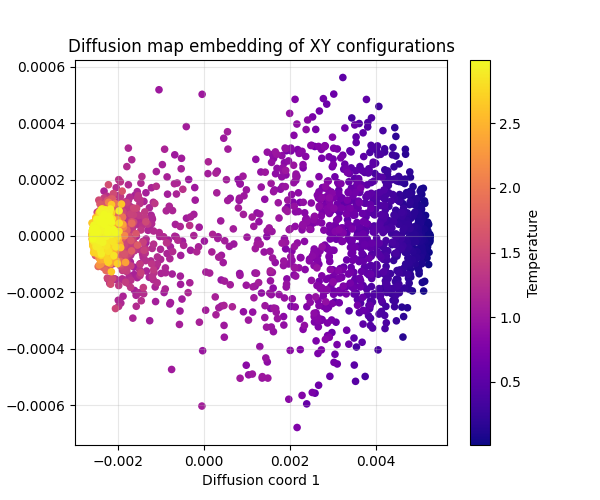

In [20]:
# Plot first two diffusion coordinates colored by temperature
plt.figure(figsize=(6, 5))
sc = plt.scatter(embeddings[:, 0], embeddings[:, 1], c=temperatures, cmap='plasma', s=30, edgecolor='none')
plt.xlabel('Diffusion coord 1')
plt.ylabel('Diffusion coord 2')
plt.title('Diffusion map embedding of XY configurations')
cb = plt.colorbar(sc)
cb.set_label('Temperature')
plt.grid(alpha=0.3)
plt.show()


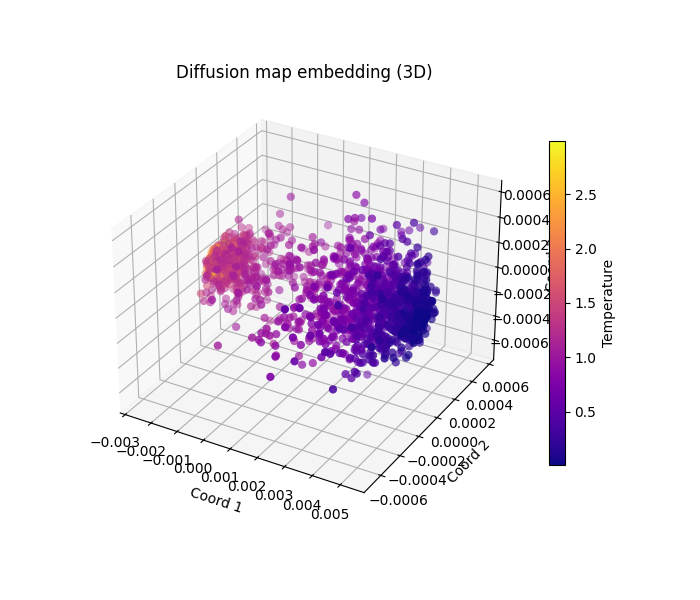

In [21]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    embeddings[:, 2],
    c=temperatures,
    cmap='plasma',
    s=35,
    edgecolor='none'
)

ax.set_xlabel('Coord 1')
ax.set_ylabel('Coord 2')
ax.set_zlabel('Coord 3')
ax.set_title('Diffusion map embedding (3D)')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Temperature')

plt.show()



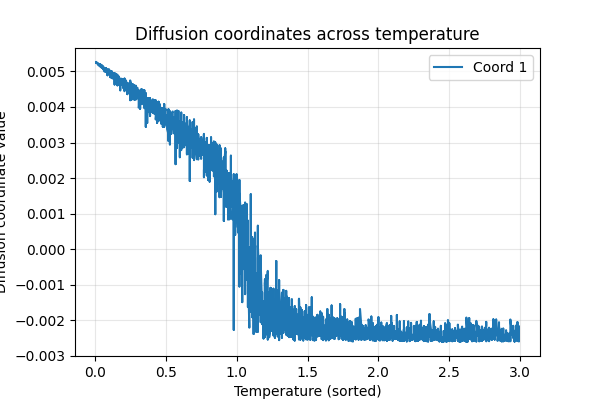

In [23]:
# Optional: inspect embeddings vs temperature ordering
order = np.argsort(temperatures)
plt.figure(figsize=(6, 4))
plt.plot(temperatures[order], embeddings[order, 0], label='Coord 1')
# plt.plot(temperatures[order], embeddings[order, 1], label='Coord 2')
# plt.plot(temperatures[order], embeddings[order, 2], label='Coord 3')
# plt.plot(temperatures[order], embeddings[order, 3], label='Coord 4')
# plt.plot(temperatures[order], embeddings[order, 4], label='Coord 5')
plt.xlabel('Temperature (sorted)')
plt.ylabel('Diffusion coordinate value')
plt.title('Diffusion coordinates across temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Pseudo-critical T from derivative: 1.0800
Pseudo-critical T from variance:   0.9800


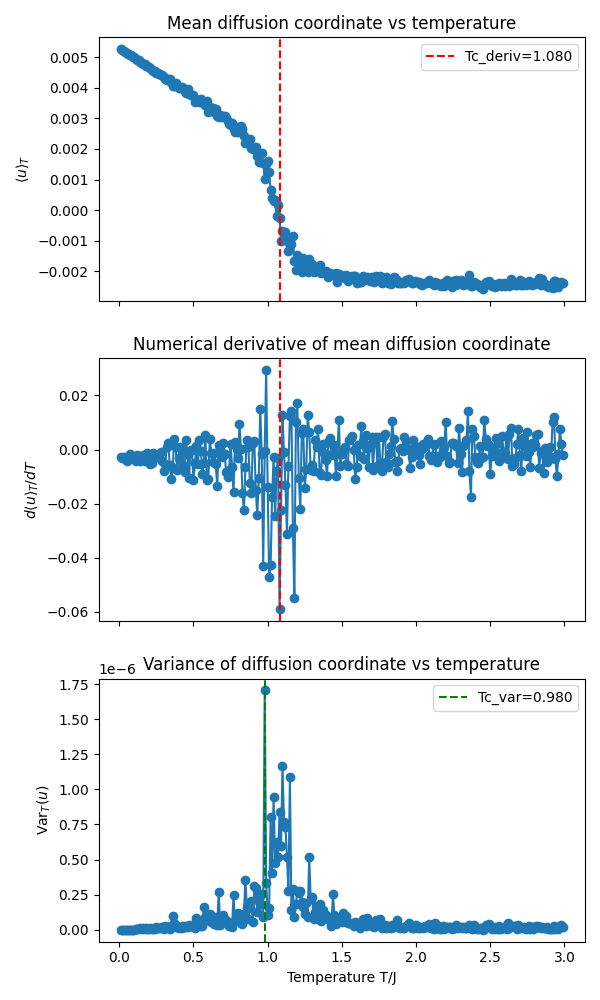

In [25]:
from collections import defaultdict

# We'll use the first nontrivial coordinate as u
u = embeddings[:, 0]   # shape: (num_samples,)

# ---------------------------------------------------------
# 2. Group u by temperature and compute mean / variance
# ---------------------------------------------------------

# Collect values per discrete temperature
values_by_T = defaultdict(list)
for ui, Ti in zip(u, temperatures):
    values_by_T[Ti].append(ui)

unique_T = np.array(sorted(values_by_T.keys()))
mean_u = np.empty_like(unique_T)
var_u  = np.empty_like(unique_T)

for k, T in enumerate(unique_T):
    arr = np.array(values_by_T[T])
    mean_u[k] = arr.mean()
    var_u[k]  = arr.var(ddof=1)  # use sample variance

# ---------------------------------------------------------
# 3. Numerical derivative of mean_u vs T
# ---------------------------------------------------------

# Central finite difference via numpy.gradient
dmean_dT = np.gradient(mean_u, unique_T)

# Pseudo-critical temperatures:
# - from maximum |d(mean_u)/dT|
# - from maximum variance of u
idx_deriv = np.argmax(np.abs(dmean_dT))
idx_var   = np.argmax(var_u)

Tc_deriv = unique_T[idx_deriv]
Tc_var   = unique_T[idx_var]

print(f"Pseudo-critical T from derivative: {Tc_deriv:.4f}")
print(f"Pseudo-critical T from variance:   {Tc_var:.4f}")

# ---------------------------------------------------------
# 4. Plots: mean_u, derivative, and variance vs T
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

# (a) mean diffusion coordinate vs T
axes[0].plot(unique_T, mean_u, marker='o', ls='-')
axes[0].axvline(Tc_deriv, color='r', ls='--', label=f"Tc_deriv={Tc_deriv:.3f}")
axes[0].set_ylabel(r"$\langle u \rangle_T$")
axes[0].set_title("Mean diffusion coordinate vs temperature")
axes[0].legend()

# (b) derivative
axes[1].plot(unique_T, dmean_dT, marker='o', ls='-')
axes[1].axvline(Tc_deriv, color='r', ls='--')
axes[1].set_ylabel(r"$d\langle u \rangle_T / dT$")
axes[1].set_title("Numerical derivative of mean diffusion coordinate")

# (c) variance
axes[2].plot(unique_T, var_u, marker='o', ls='-')
axes[2].axvline(Tc_var, color='g', ls='--', label=f"Tc_var={Tc_var:.3f}")
axes[2].set_xlabel("Temperature T/J")
axes[2].set_ylabel(r"${\rm Var}_T(u)$")
axes[2].set_title("Variance of diffusion coordinate vs temperature")
axes[2].legend()

plt.tight_layout()
plt.show()

## Interactive exploration

Use the widgets below to explore the diffusion-map coordinates interactively. You can filter by temperature range, pick which diffusion coordinates to examine, adjust the point size, or toggle a 3D view.

In [7]:
import ipywidgets as widgets
from IPython.display import display

coord_options = {
    'Coord 1 vs 2': (0, 1),
    'Coord 1 vs 3': (0, 2),
    'Coord 2 vs 3': (1, 2),
}

temp_min = float(temperatures.min())
temp_max = float(temperatures.max())

temp_slider = widgets.FloatRangeSlider(
    value=(temp_min, temp_max),
    min=temp_min,
    max=temp_max,
    step=0.01,
    description='Temp range',
    continuous_update=False,
    layout=widgets.Layout(width='70%')
)

coord_dropdown = widgets.Dropdown(
    options=[(label, pair) for label, pair in coord_options.items()],
    value=(0, 1),
    description='2D axes'
)

size_slider = widgets.IntSlider(value=35, min=10, max=120, step=5, description='Point size')
show_3d_checkbox = widgets.Checkbox(value=False, description='3D scatter')

@widgets.interact(
    coord_pair=coord_dropdown,
    temp_range=temp_slider,
    point_size=size_slider,
    show_3d=show_3d_checkbox,
)
def interactive_diffusion(coord_pair, temp_range, point_size, show_3d):
    mask = (temperatures >= temp_range[0]) & (temperatures <= temp_range[1])
    if not np.any(mask):
        print('No samples in the selected temperature window.')
        return

    if show_3d:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection='3d')
        coords3d = embeddings[mask, :3]
        sc = ax.scatter(
            coords3d[:, 0], coords3d[:, 1], coords3d[:, 2],
            c=temperatures[mask], cmap='plasma', s=point_size, edgecolor='none'
        )
        ax.set_xlabel('Coord 1')
        ax.set_ylabel('Coord 2')
        ax.set_zlabel('Coord 3')
        ax.set_title('Diffusion map embedding (interactive 3D)')
        fig.colorbar(sc, ax=ax, shrink=0.7, label='Temperature')
        plt.show()
        return

    x_idx, y_idx = coord_pair
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        embeddings[mask, x_idx],
        embeddings[mask, y_idx],
        c=temperatures[mask],
        cmap='plasma',
        s=point_size,
        edgecolor='none'
    )
    ax.set_xlabel(f'Diffusion coord {x_idx + 1}')
    ax.set_ylabel(f'Diffusion coord {y_idx + 1}')
    ax.set_title('Diffusion map (interactive 2D)')
    fig.colorbar(sc, ax=ax, label='Temperature')
    ax.grid(alpha=0.3)
    plt.show()


interactive(children=(Dropdown(description='2D axes', options=(('Coord 1 vs 2', (0, 1)), ('Coord 1 vs 3', (0, …